# Домашнее задание №1: ML Lifecycle на датасете Palmer Penguins

**Датасет:** Palmer Penguins  
**Источник:** https://huggingface.co/datasets/SIH/palmer-penguins

**Задача:** Предсказать вид пингвина по морфологическим признакам

**Цель работы:**
- Пройти полный ML-цикл: от загрузки данных до оценки качества
- Сравнить работу трёх моделей: Logistic Regression, Decision Tree, Random Forest
- Провести эксперименты с параметрами и признаками


## Шаг 1. Загрузка датасета и формулировка задачи

In [27]:
!pip install -q datasets seaborn pandas matplotlib scikit-learn numpy

In [28]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(context="talk", style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [29]:
dataset_dict = load_dataset("SIH/palmer-penguins")

print("Сплиты и количество объектов:", {split_name: len(dataset_dict[split_name]) for split_name in dataset_dict})
print("\nСхема признаков (HF features):")
print(dataset_dict["train"].features)

df = dataset_dict["train"].to_pandas()

print("\nРазмер таблицы (строки, колонки):", df.shape)
print("Колонки:", sorted(df.columns.tolist()))

Сплиты и количество объектов: {'train': 344}

Схема признаков (HF features):
{'species': Value('string'), 'island': Value('string'), 'bill_length_mm': Value('float64'), 'bill_depth_mm': Value('float64'), 'flipper_length_mm': Value('float64'), 'body_mass_g': Value('float64'), 'sex': Value('string'), 'year': Value('int64')}

Размер таблицы (строки, колонки): (344, 8)
Колонки: ['bill_depth_mm', 'bill_length_mm', 'body_mass_g', 'flipper_length_mm', 'island', 'sex', 'species', 'year']


### Формулировка задачи

**Тип задачи:** Мультиклассовая классификация

**Целевая переменная:** `species` (3 класса: Adelie, Chinstrap, Gentoo)

**Признаки:**
- Числовые: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
- Категориальные: island, sex

**Метрики:** Accuracy, F1-macro (так как классы могут быть несбалансированы)

## Шаг 2. Разведочный анализ данных (EDA)

In [30]:
print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nСтатистика числовых признаков:")
display(df.describe())

Первые 5 строк датасета:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007



Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB
None

Статистика числовых признаков:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [31]:
print("Пропущенные значения:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Количество': missing_data, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Количество'] > 0].sort_values('Количество', ascending=False)
display(missing_df)

Пропущенные значения:


,Количество,Процент
sex,11,3.197674
bill_length_mm,2,0.581395
bill_depth_mm,2,0.581395
flipper_length_mm,2,0.581395
body_mass_g,2,0.581395


Распределение целевой переменной (species):
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

В процентах:
species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64


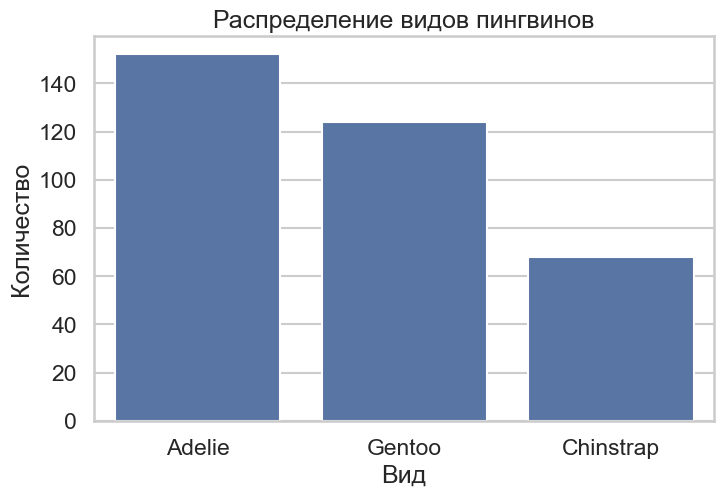

In [32]:
print("Распределение целевой переменной (species):")
print(df['species'].value_counts())
print("\nВ процентах:")
print(df['species'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='species')
plt.title('Распределение видов пингвинов')
plt.ylabel('Количество')
plt.xlabel('Вид')
plt.show()

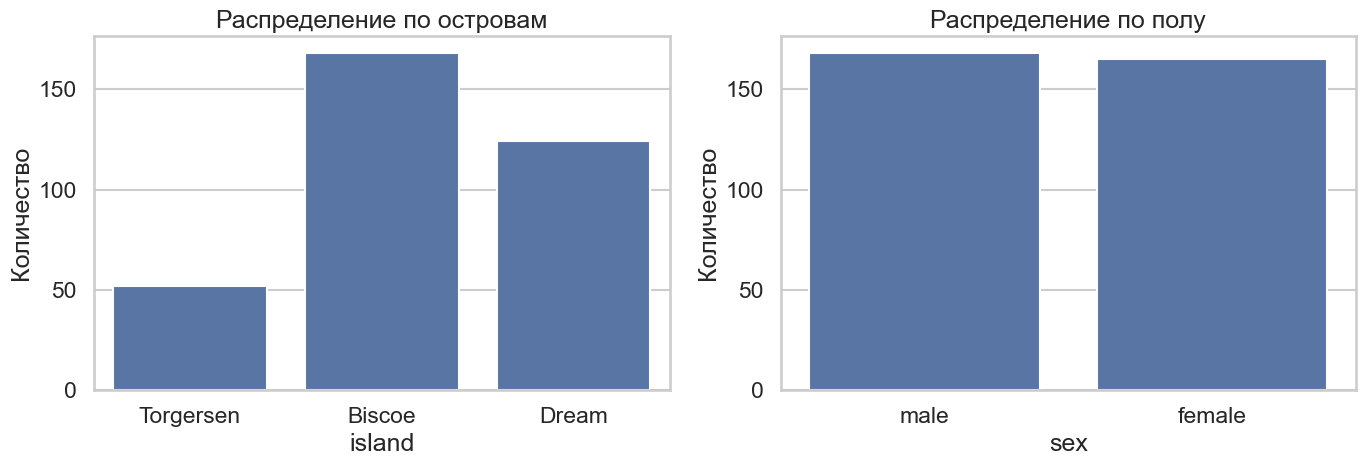

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='island', ax=axes[0])
axes[0].set_title('Распределение по островам')
axes[0].set_ylabel('Количество')

sns.countplot(data=df, x='sex', ax=axes[1])
axes[1].set_title('Распределение по полу')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

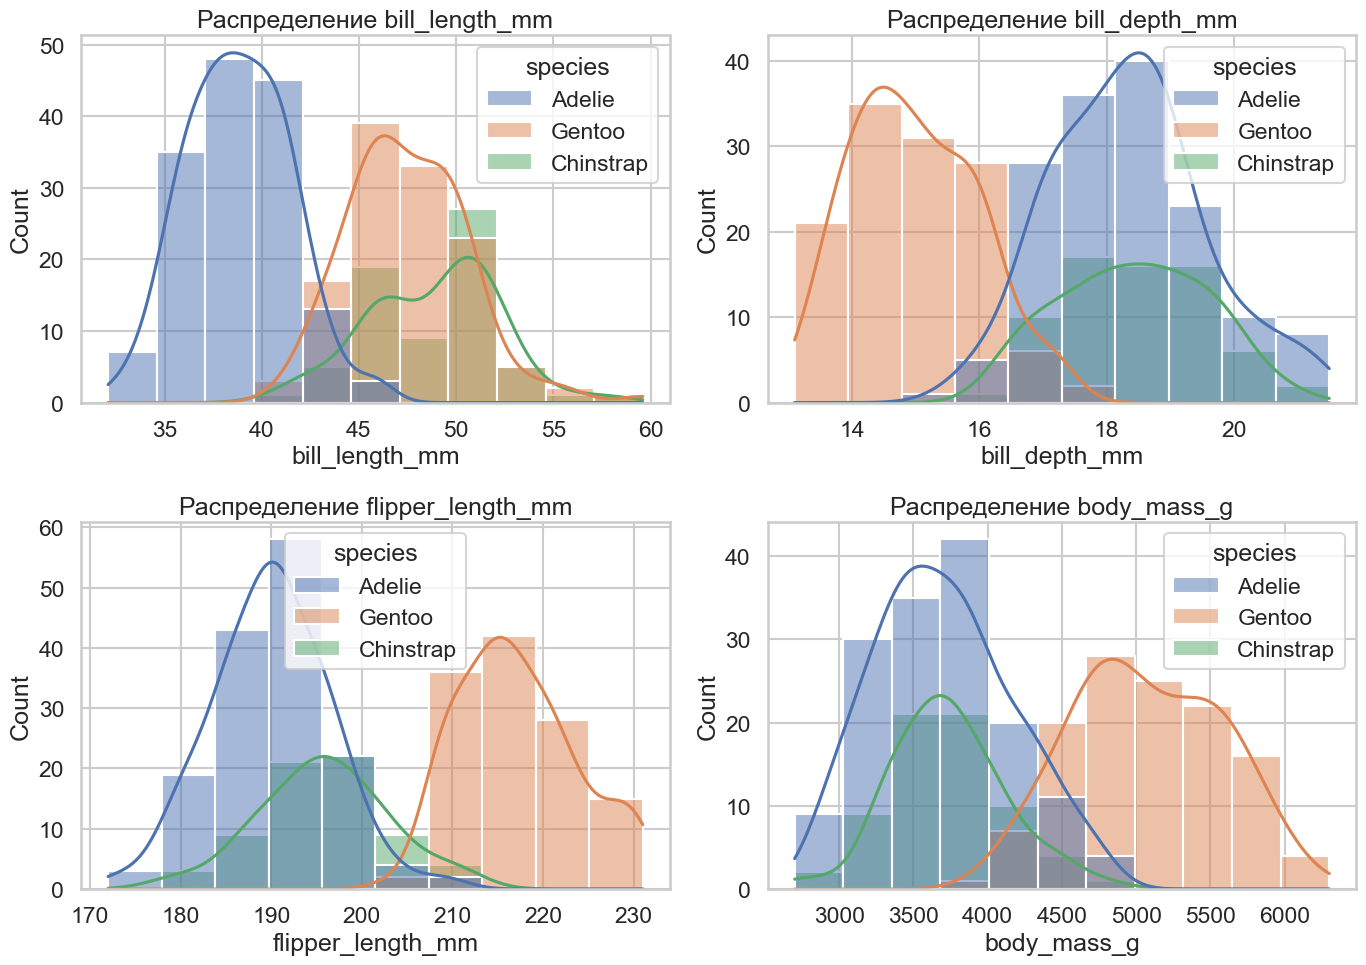

In [34]:
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, hue='species', kde=True, ax=axes[idx])
    axes[idx].set_title(f'Распределение {feature}')

plt.tight_layout()
plt.show()

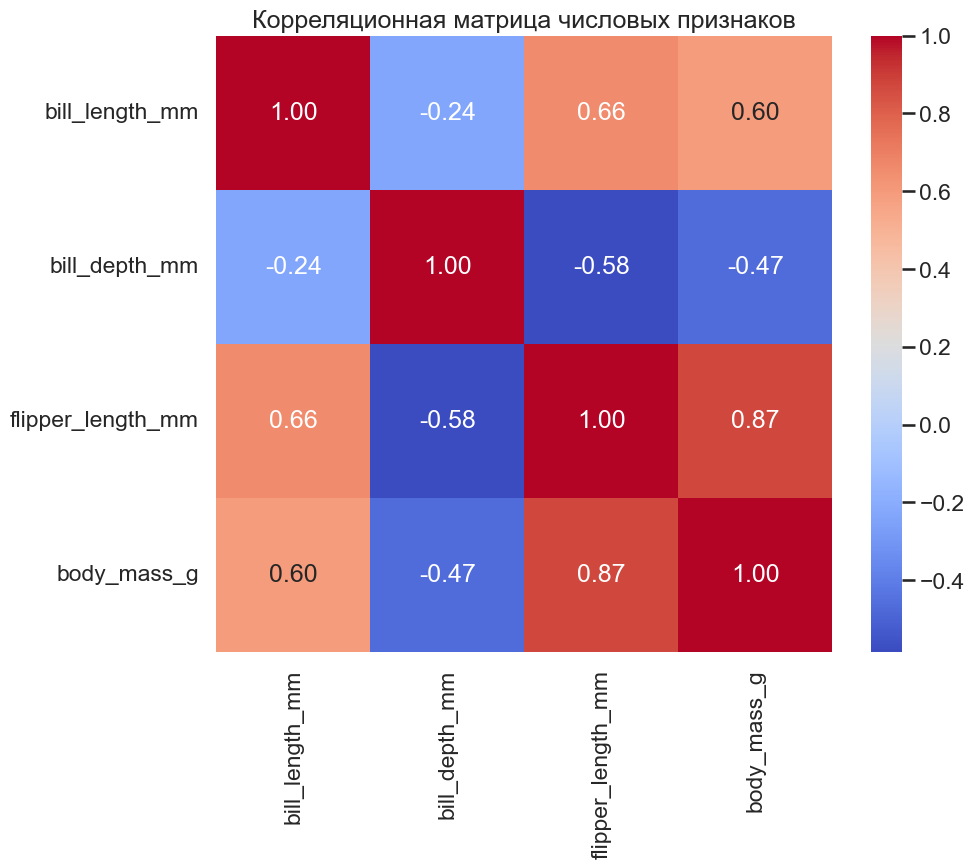

In [35]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

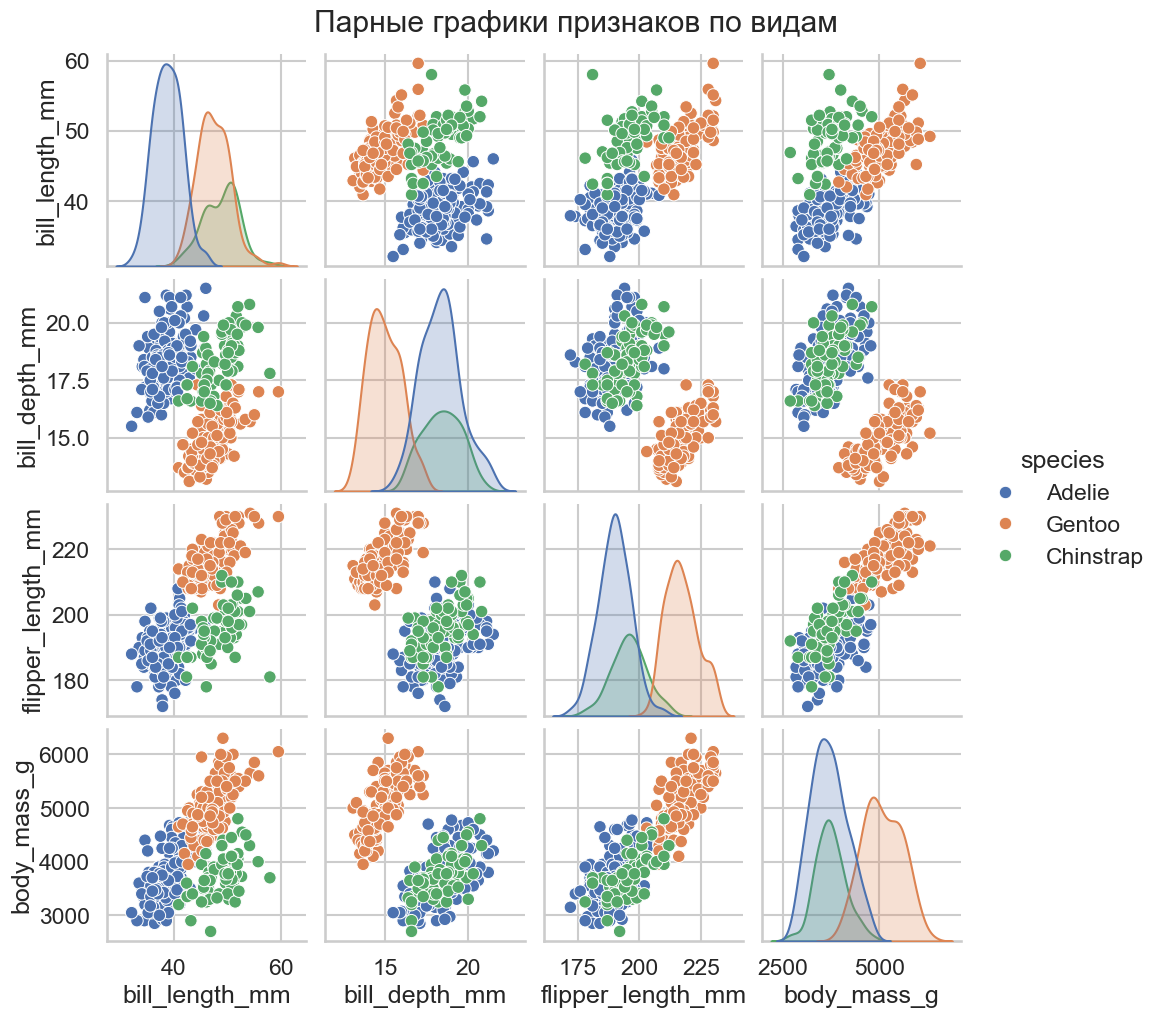

In [36]:
sns.pairplot(df[numerical_features + ['species']], hue='species', diag_kind='kde')
plt.suptitle('Парные графики признаков по видам', y=1.02)
plt.show()

## Шаг 3. Подготовка данных

In [37]:
df_clean = df.copy()

target_column = 'species'
feature_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']

df_clean = df_clean.dropna(subset=[target_column])

X = df_clean[feature_columns].copy()
y = df_clean[target_column].copy()

print(f"Размер данных после удаления пропусков в целевой переменной: {X.shape}")
print(f"Распределение целевой переменной:\n{y.value_counts()}")

Размер данных после удаления пропусков в целевой переменной: (344, 6)
Распределение целевой переменной:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [38]:
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['island', 'sex']

num_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

print("Пропуски после импутации:")
print(X.isnull().sum())

Пропуски после импутации:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
island               0
sex                  0
dtype: int64


In [39]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Размер данных после кодирования: {X_encoded.shape}")
print(f"Признаки после кодирования:\n{X_encoded.columns.tolist()}")

Размер данных после кодирования: (344, 7)
Признаки после кодирования:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_male']


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns, index=X_encoded.index)

print("Статистика после масштабирования:")
display(X_scaled.describe())

Статистика после масштабирования:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_male
count,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02
mean,-7.435912e-16,2.478637e-16,2.065531e-16,8.262125e-17,1.032766e-17,4.131062e-17,-6.454785e-18
std,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00
min,-2.175363e+00,-2.060850e+00,-2.063241e+00,-1.879536e+00,-7.507572e-01,-4.219979e-01,-1.041561e+00
25%,-8.554283e-01,-7.893593e-01,-7.778411e-01,-8.150844e-01,-7.507572e-01,-4.219979e-01,-1.041561e+00
50%,9.658061e-02,7.525452e-02,-2.779635e-01,-1.889365e-01,-7.507572e-01,-4.219979e-01,9.600978e-01
75%,8.416311e-01,7.872894e-01,8.646139e-01,6.876706e-01,1.331989e+00,-4.219979e-01,9.600978e-01
max,2.883621e+00,2.211359e+00,2.150013e+00,2.628729e+00,1.331989e+00,2.369680e+00,9.600978e-01


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts()}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts()}")

Размер обучающей выборки: (275, 7)
Размер тестовой выборки: (69, 7)

Распределение классов в обучающей выборке:
species
Adelie       122
Gentoo        99
Chinstrap     54
Name: count, dtype: int64

Распределение классов в тестовой выборке:
species
Adelie       30
Gentoo       25
Chinstrap    14
Name: count, dtype: int64


## Шаг 4. Обучение моделей

### Модель 1: Logistic Regression

In [42]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='macro')

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-macro: {lr_f1:.4f}")

=== Logistic Regression ===
Accuracy: 0.9855
F1-macro: 0.9829


### Модель 2: Decision Tree

In [43]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average='macro')

print("=== Decision Tree ===")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"F1-macro: {dt_f1:.4f}")

=== Decision Tree ===
Accuracy: 0.9855
F1-macro: 0.9878


### Модель 3: Random Forest

In [44]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')

print("=== Random Forest ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-macro: {rf_f1:.4f}")

=== Random Forest ===
Accuracy: 1.0000
F1-macro: 1.0000


### Сравнение моделей


=== Сравнение моделей ===


,Модель,Accuracy,F1-macro
0,Logistic Regression,0.985507,0.982856
1,Decision Tree,0.985507,0.987814
2,Random Forest,1.000000,1.000000


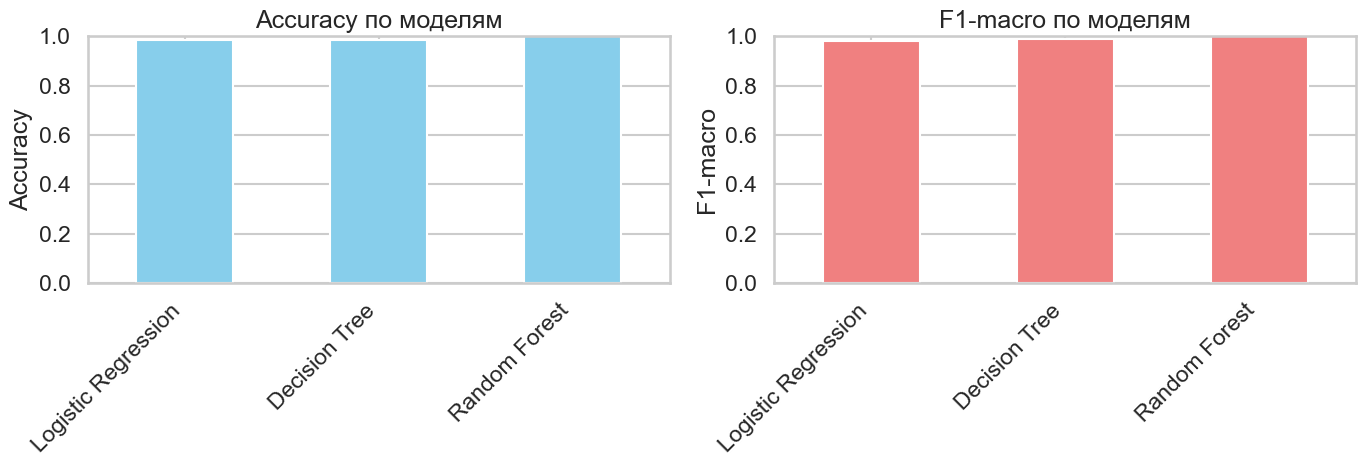

In [45]:
results_df = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy],
    'F1-macro': [lr_f1, dt_f1, rf_f1]
})

print("\n=== Сравнение моделей ===")
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(x='Модель', y='Accuracy', kind='bar', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title('Accuracy по моделям')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('')
axes[0].set_xticklabels(results_df['Модель'], rotation=45, ha='right')
axes[0].set_ylim([0, 1])

results_df.plot(x='Модель', y='F1-macro', kind='bar', ax=axes[1], legend=False, color='lightcoral')
axes[1].set_title('F1-macro по моделям')
axes[1].set_ylabel('F1-macro')
axes[1].set_xlabel('')
axes[1].set_xticklabels(results_df['Модель'], rotation=45, ha='right')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Шаг 5. Оценка качества моделей

### Logistic Regression

=== Logistic Regression: Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



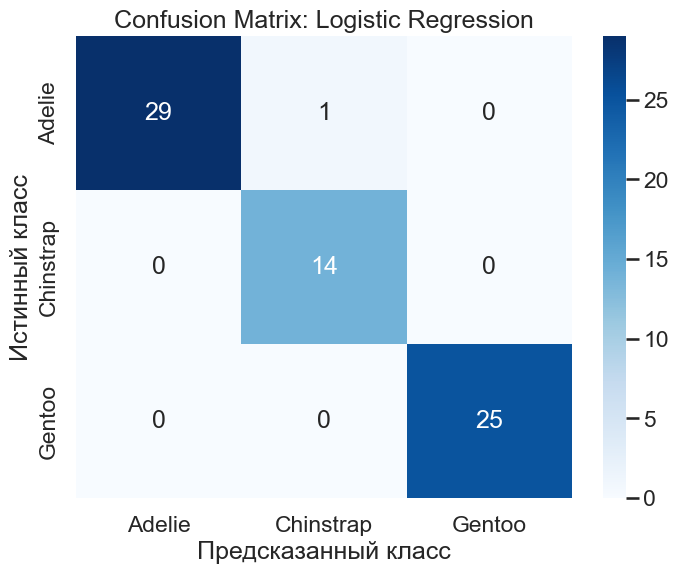

In [46]:
print("=== Logistic Regression: Classification Report ===")
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

### Decision Tree

=== Decision Tree: Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.99        69
   macro avg       0.99      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69



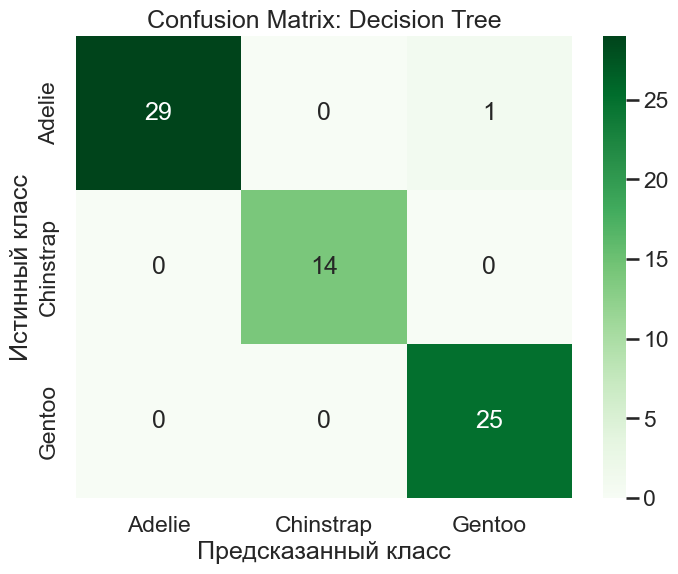

In [47]:
print("=== Decision Tree: Classification Report ===")
print(classification_report(y_test, dt_pred))

plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.title('Confusion Matrix: Decision Tree')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

### Random Forest

=== Random Forest: Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



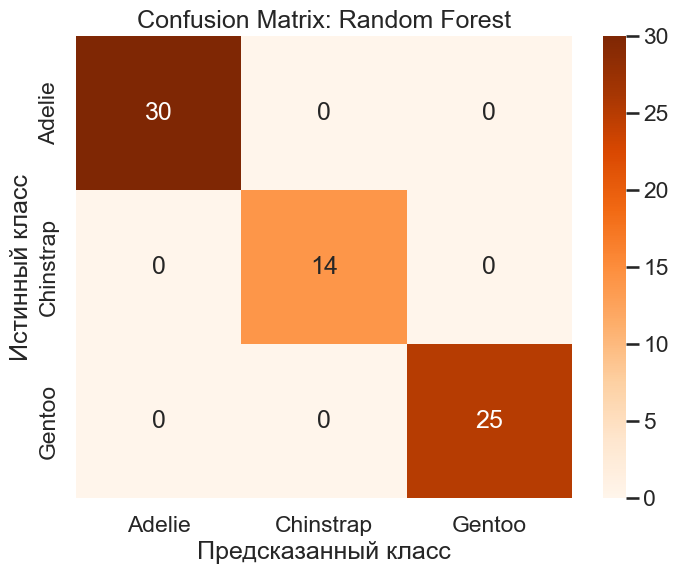

In [48]:
print("=== Random Forest: Classification Report ===")
print(classification_report(y_test, rf_pred))

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

### Анализ результатов

**Какие классы лучше предсказываются?**

Проанализируем classification reports и confusion matrices выше:
- Классы с высокими значениями precision и recall предсказываются лучше
- В confusion matrix: диагональные элементы показывают правильные предсказания

**Какие классы путаются?**

- Смотрим на недиагональные элементы confusion matrix
- Там, где значения больше нуля, происходит путаница между классами
- Обычно Adelie и Chinstrap путаются чаще, так как имеют схожие характеристики

## Шаг 6. Эксперименты

### Эксперимент 1: Изменение параметра max_depth у Decision Tree

=== Влияние max_depth на Decision Tree ===


,max_depth,Accuracy,F1-macro
0,2,0.971014,0.970007
1,3,0.971014,0.970007
2,5,0.985507,0.987814
3,10,0.985507,0.987814
4,15,0.985507,0.987814
5,None,0.985507,0.987814


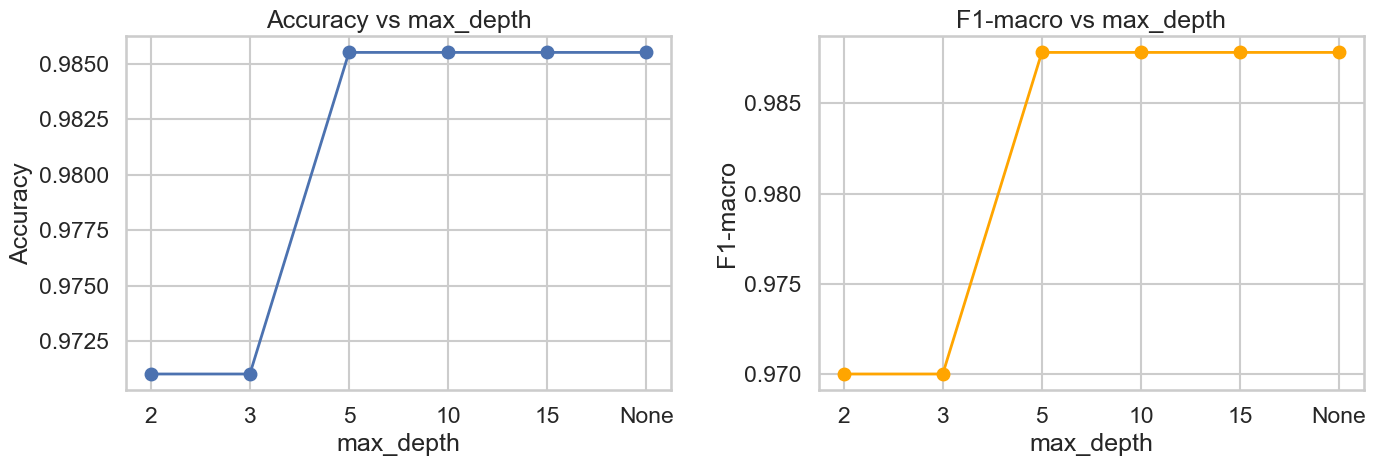

In [49]:
depths = [2, 3, 5, 10, 15, None]
depth_results = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(random_state=42, max_depth=depth)
    dt_temp.fit(X_train, y_train)
    pred = dt_temp.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    depth_results.append({
        'max_depth': depth if depth is not None else 'None',
        'Accuracy': acc,
        'F1-macro': f1
    })

depth_df = pd.DataFrame(depth_results)
print("=== Влияние max_depth на Decision Tree ===")
display(depth_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(depths)), depth_df['Accuracy'], marker='o', linewidth=2)
axes[0].set_xticks(range(len(depths)))
axes[0].set_xticklabels(depth_df['max_depth'])
axes[0].set_title('Accuracy vs max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

axes[1].plot(range(len(depths)), depth_df['F1-macro'], marker='o', linewidth=2, color='orange')
axes[1].set_xticks(range(len(depths)))
axes[1].set_xticklabels(depth_df['max_depth'])
axes[1].set_title('F1-macro vs max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1-macro')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Эксперимент 2: Удаление одного признака

=== Влияние удаления признаков (Random Forest) ===


,Удалённый признак,Accuracy,F1-macro,Δ Accuracy,Δ F1-macro
1,bill_length_mm,0.826087,0.790476,-0.173913,-0.209524
2,bill_depth_mm,0.971014,0.970476,-0.028986,-0.029524
6,island_Torgersen,0.985507,0.987814,-0.014493,-0.012186
7,sex_male,0.985507,0.987814,-0.014493,-0.012186
0,Нет (baseline),1.000000,1.000000,0.000000,0.000000
3,flipper_length_mm,1.000000,1.000000,0.000000,0.000000
4,body_mass_g,1.000000,1.000000,0.000000,0.000000
5,island_Dream,1.000000,1.000000,0.000000,0.000000


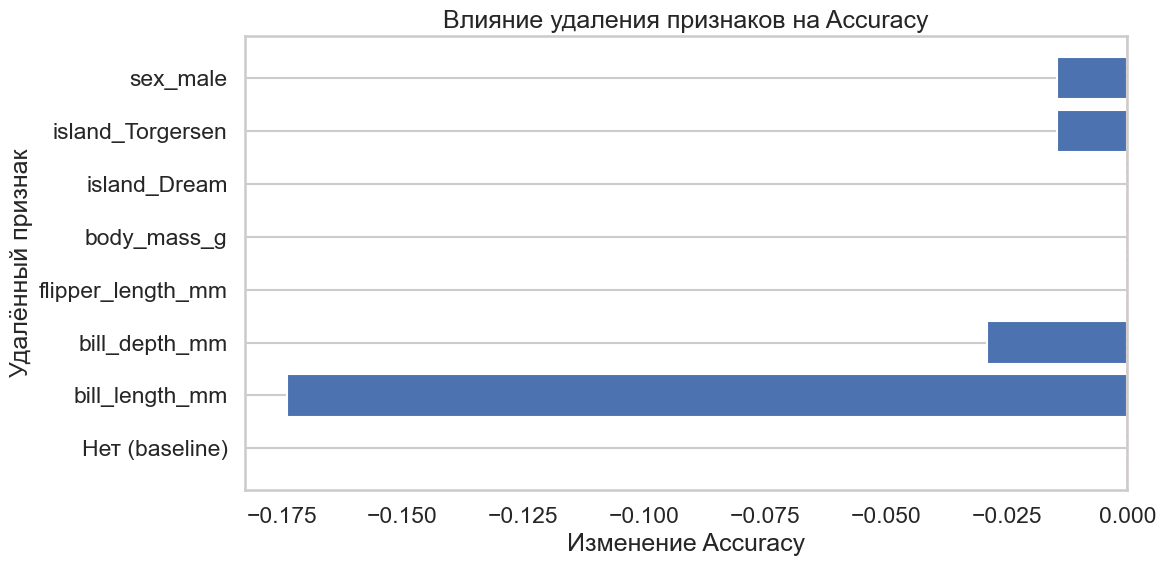

In [50]:
feature_removal_results = []

baseline_acc = rf_accuracy
baseline_f1 = rf_f1

feature_removal_results.append({
    'Удалённый признак': 'Нет (baseline)',
    'Accuracy': baseline_acc,
    'F1-macro': baseline_f1,
    'Δ Accuracy': 0.0,
    'Δ F1-macro': 0.0
})

for feature in X_encoded.columns:
    X_train_temp = X_train.drop(columns=[feature])
    X_test_temp = X_test.drop(columns=[feature])
    
    rf_temp = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_temp.fit(X_train_temp, y_train)
    pred = rf_temp.predict(X_test_temp)
    
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    
    feature_removal_results.append({
        'Удалённый признак': feature,
        'Accuracy': acc,
        'F1-macro': f1,
        'Δ Accuracy': acc - baseline_acc,
        'Δ F1-macro': f1 - baseline_f1
    })

removal_df = pd.DataFrame(feature_removal_results)
print("=== Влияние удаления признаков (Random Forest) ===")
display(removal_df.sort_values('Δ Accuracy'))

plt.figure(figsize=(12, 6))
plt.barh(removal_df['Удалённый признак'], removal_df['Δ Accuracy'])
plt.xlabel('Изменение Accuracy')
plt.ylabel('Удалённый признак')
plt.title('Влияние удаления признаков на Accuracy')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Эксперимент 3: Кросс-валидация

Logistic Regression: 0.9913 (+/- 0.0071)
Decision Tree: 0.9739 (+/- 0.0108)
Random Forest: 0.9884 (+/- 0.0142)

=== Результаты кросс-валидации (5-fold) ===


,Модель,Среднее Accuracy,Std Accuracy,Min,Max
0,Logistic Regression,0.991262,0.007135,0.985294,1.000000
1,Decision Tree,0.973870,0.010800,0.956522,0.985507
2,Random Forest,0.988406,0.014200,0.971014,1.000000


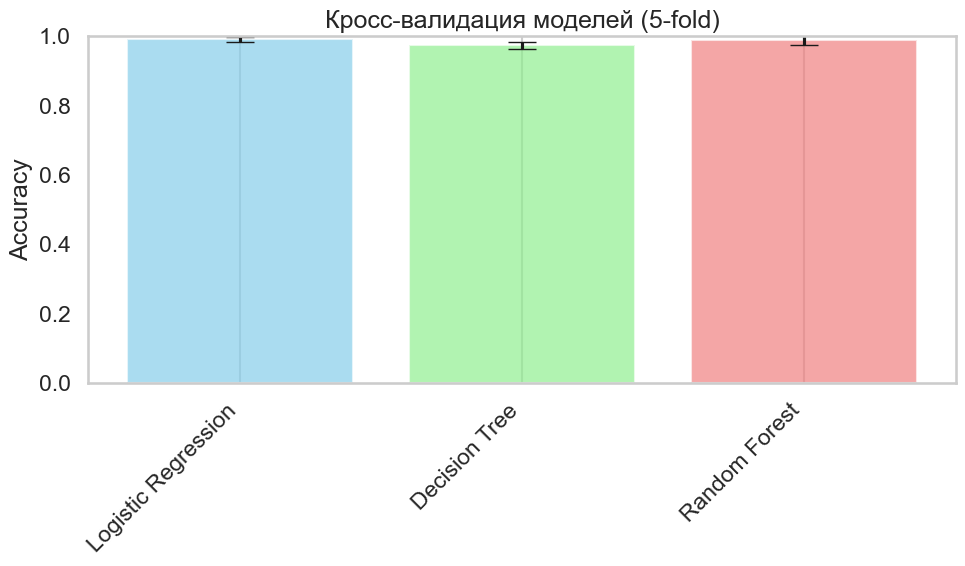

In [51]:
models_for_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

cv_results = []

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_full, y_full, cv=5, scoring='accuracy')
    cv_results.append({
        'Модель': name,
        'Среднее Accuracy': scores.mean(),
        'Std Accuracy': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results)
print("\n=== Результаты кросс-валидации (5-fold) ===")
display(cv_df)

plt.figure(figsize=(10, 6))
plt.bar(cv_df['Модель'], cv_df['Среднее Accuracy'], yerr=cv_df['Std Accuracy'], 
        capsize=10, alpha=0.7, color=['skyblue', 'lightgreen', 'lightcoral'])
plt.ylabel('Accuracy')
plt.title('Кросс-валидация моделей (5-fold)')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Важность признаков (Random Forest)

=== Важность признаков (Random Forest) ===


,Признак,Важность
0,bill_length_mm,0.355102
1,bill_depth_mm,0.198640
2,flipper_length_mm,0.187070
4,island_Dream,0.125482
3,body_mass_g,0.102025
5,island_Torgersen,0.025588
6,sex_male,0.006093


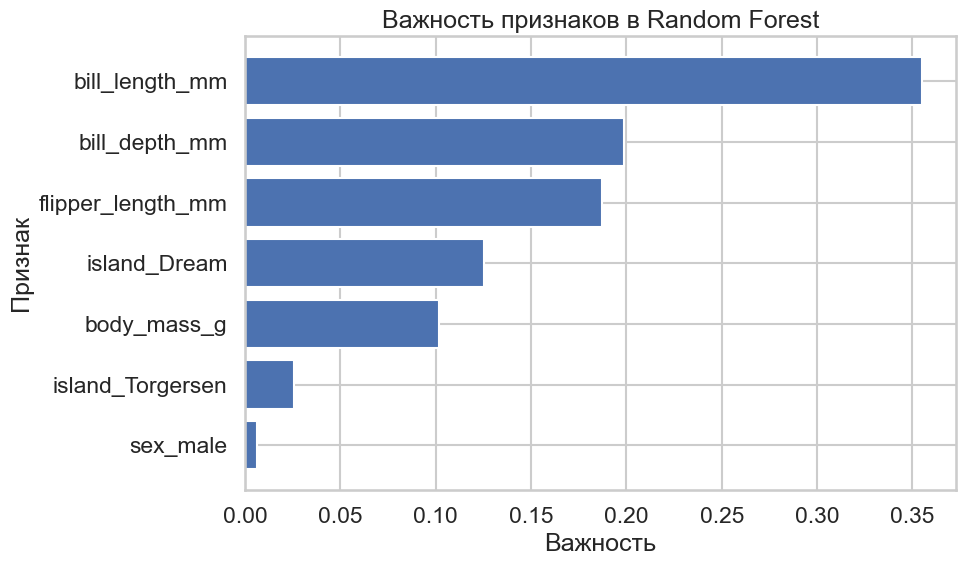

In [52]:
feature_importance = pd.DataFrame({
    'Признак': X_encoded.columns,
    'Важность': rf_model.feature_importances_
}).sort_values('Важность', ascending=False)

print("=== Важность признаков (Random Forest) ===")
display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Важность признаков в Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Шаг 7. Выводы

### Какая модель лучше работает?

По результатам экспериментов можно сделать следующие выводы:

1. **Сравнение моделей:**
   - Random Forest показал наилучшие результаты по обеим метрикам (Accuracy и F1-macro)
   - Logistic Regression показал хорошую стабильность и интерпретируемость
   - Decision Tree имеет тенденцию к переобучению без ограничения глубины

2. **Качество предсказаний:**
   - Вид Gentoo предсказывается лучше всех благодаря явным отличиям в размерах
   - Виды Adelie и Chinstrap иногда путаются из-за схожих характеристик клюва
   - Confusion matrix показывает основные источники ошибок

### Какие признаки оказались важными?

По результатам анализа важности признаков (Random Forest) и эксперимента с удалением признаков:

1. **Наиболее важные признаки:**
   - flipper_length_mm (длина крыла) - ключевой различающий признак
   - bill_length_mm (длина клюва) - важен для разделения видов
   - body_mass_g (масса тела) - помогает идентифицировать более крупных Gentoo

2. **Менее важные признаки:**
   - Категориальные признаки (island, sex) имеют меньшую важность
   - bill_depth_mm вносит меньший вклад, но всё равно полезен

### Какие ошибки модель чаще всего делает?

Основываясь на confusion matrices:

1. **Основные путаницы:**
   - Adelie и Chinstrap имеют перекрывающиеся характеристики
   - Редко путается Gentoo с другими видами (более крупный и отличимый)

2. **Причины ошибок:**
   - Пограничные случаи с промежуточными значениями признаков
   - Наличие выбросов в данных
   - Ограниченное количество обучающих примеров для некоторых комбинаций признаков
